In [ ]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
raw_data = pd.read_csv('gun-violence-data_01-2013_03-2018.csv')

<ipython-input-12-922df5d59d8f>:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_data[col].fillna(raw_data[col].mean(), inplace=True)


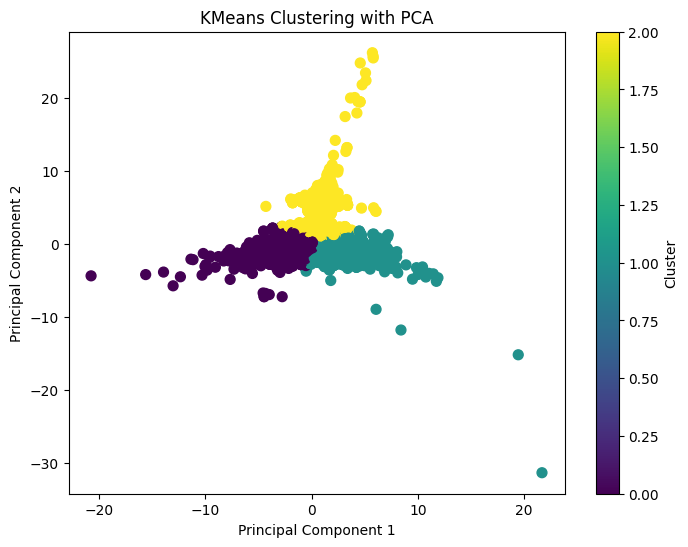

           incident_id  n_killed  n_injured  congressional_district  \
cluster                                                               
0        557558.513023  0.022608   0.760086                6.976446   
1        556691.261139  0.842888   0.090461                9.878133   
2        569381.163987  0.106527   0.227898                8.535882   

          latitude   longitude  n_guns_involved  state_house_district  \
cluster                                                                 
0        37.864119  -83.443376         1.247681             59.562462   
1        34.403114  -89.409800         1.227964             60.265110   
2        41.354728 -108.980024         2.014406             35.780680   

         state_senate_district     month  cluster  
cluster                                            
0                    21.153436  6.394738      0.0  
1                    19.741941  6.311985      1.0  
2                    19.551866  6.269554      2.0  


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

features = ['n_killed', 'n_injured', 'n_guns_involved', 'latitude', 'longitude']

for col in features:
  if raw_data[col].isnull().any():
    if pd.api.types.is_numeric_dtype(raw_data[col]):
      raw_data[col].fillna(raw_data[col].mean(), inplace=True)
    else:
      raw_data[col].fillna(raw_data[col].mode()[0], inplace=True)

X = raw_data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=3)
kmeans.fit(X_pca)
labels = kmeans.labels_

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('KMeans Clustering with PCA')
plt.colorbar(label='Cluster')
plt.show()

raw_data['cluster'] = labels

numeric_cols = raw_data.select_dtypes(include=np.number).columns
print(raw_data.groupby('cluster')[numeric_cols].mean())

In [ ]:
'''

## Cluster 0 (“Injury-only, big cities”)

* **Cities/counties:** Chicago, Baltimore, Washington DC
* **States:** Illinois, New York, Ohio
* **Gun stolen?** Almost always “Unknown”
* **Gun type:** Unknown most often, then Handguns and 9 mm
* **Incident characteristics:**

  * “Shot – Wounded/Injured” dominates
  * Lots of “Shots Fired – No Injuries” events
* **Participant status/type:** Primarily **Injured** **Victims**, age 18–25, mostly **Male**
* **Months:** January, March, August

> **Takeaway:** these are concentrates of non-fatal, injury-heavy shootings in large East Coast/Midwestern cities, typically involving single, unknown handguns and young male victims.

---

## Cluster 1 (“Lethal, Gulf/South”)

* **Cities/counties:** Houston, New Orleans, Oakland/Portland (note mix of TX/LA/CA)
* **States:** Florida, Texas, Louisiana
* **Gun stolen?** Mostly “Unknown,” with a smaller fraction marked “Stolen”
* **Gun type:** Again “Unknown” or Handgun
* **Incident characteristics:**

  * “Shot – Dead (murder…)” is the #1 label
  * Followed by mixed “Wounded/Injured” + “Dead” combos
* **Participant status/type:** Predominantly **Killed** participants (often Suspect-Victims)
* **Months:** July, March, January

> **Takeaway:** this cluster captures the more deadly shootings—higher fatality rate—often in Gulf-region cities, with events coded as outright homicides.

---

## Cluster 2 (“No-injury/Arrests, Western US”)

* **Cities/counties:** Fresno, plus scattered smaller counties
* **States:** California, Washington, Illinois
* **Gun stolen?** Mix of “Unknown” and some “Stolen”
* **Gun type:** Unknown or Handgun
* **Incident characteristics:**

  * A lot of “Shots Fired – No Injuries”
  * Some “Wounded/Injured,” but far fewer “Dead”
* **Participant status/type:** Often **Unharmed, Arrested** suspects or **Victims**
* **Months:** March, January, August

> **Takeaway:** these are largely no-casualty or arrest-heavy events out West—drive-by or shots-fired calls that end without injuries or with suspects taken into custody.

---

### How it “separates”

1. **Severity axis**

   * **Cluster 1** at the high-fatality end
   * **Cluster 0** in the middle (injuries but few deaths)
   * **Cluster 2** on the low-casualty end

2. **Geography**

   * **Cluster 0:** East Coast / Midwest big cities
   * **Cluster 1:** Gulf/South cities
   * **Cluster 2:** Western U.S.

3. **Participant outcomes**

   * **Cluster 1:** victims killed
   * **Cluster 0:** victims injured
   * **Cluster 2:** suspects arrested or no injuries

By reading off your “top-3” pivot table in exactly this way, you can succinctly describe each cluster’s unique story.

'''